<a href="https://www.kaggle.com/code/collinslemeke/autism-emotion-detection?scriptVersionId=325977345" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

#### Step 1: Setup

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data Paths
train_data_dir = '/kaggle/input/autistic-children-emotions-dr-fatma-m-talaat/Autistic Children Emotions - Dr. Fatma M. Talaat/Train'
test_data_dir = '/kaggle/input/autistic-children-emotions-dr-fatma-m-talaat/Autistic Children Emotions - Dr. Fatma M. Talaat/Test'

2025-09-09 13:19:09.370595: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757423949.757751      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757423949.856770      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


#### Step 2: Image Size and Data Augmentation for Training

In [2]:
img_size = (256, 256)
batch_size = 64

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.09,
    height_shift_range=0.09,
    shear_range=0.09,
    zoom_range=0.09,
    fill_mode='nearest',
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

#### Step 3: Load the Data

In [3]:
# Load training data
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Load validation data
validation_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Load test data
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 608 images belonging to 6 classes.
Found 150 images belonging to 6 classes.
Found 75 images belonging to 6 classes.


#### Step 4: Creating Model Architecture

In [4]:
# Use pre-trained VGG16 model without the top layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))

# Freeze the layers of the pre-trained model
for layer in base_model.layers:
    layer.trainable = False

model = Sequential()
model.add(base_model)
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(len(train_generator.class_indices), activation='softmax'))

I0000 00:00:1757423969.652732      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1757423969.653403      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### Step 5: Model Training

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/28


I0000 00:00:1757423979.006623     134 service.cc:148] XLA service 0x7fe6d0010580 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757423979.008483     134 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1757423979.008513     134 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1757423979.589151     134 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-09-09 13:19:56.133326: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng12{k11=0} for conv (f32[64,256,64,64]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,256,64,64]{3,2,1,0}, f32[256,256,3,3]{3,2,1,0}, f32[256]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_sch

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2965 - loss: 1.9622

2025-09-09 13:20:46.625980: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng12{k11=0} for conv (f32[22,512,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[22,512,32,32]{3,2,1,0}, f32[512,512,3,3]{3,2,1,0}, f32[512]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-09-09 13:20:46.894877: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.269019224s
Trying algorithm eng12{k11=0} for conv (f32[22,512,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[22,512,32,32]{3,2,1,0}, f32[512,512,3,3]{3,2,1,0}, f32[512]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward

10/10 ━━━━━━━━━━━━━━━━━━━━ 73s 5s/step - accuracy: 0.3005 - loss: 1.9503 - val_accuracy: 0.4800 - val_loss: 1.4046
Epoch 2/28
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.4290 - loss: 1.6617 - val_accuracy: 0.4733 - val_loss: 1.4001
Epoch 3/28
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.3673 - loss: 1.5297 - val_accuracy: 0.4667 - val_loss: 1.4069
Epoch 4/28
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.4702 - loss: 1.4154 - val_accuracy: 0.5000 - val_loss: 1.3626
Epoch 5/28
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.4718 - loss: 1.3691 - val_accuracy: 0.5000 - val_loss: 1.3029
Epoch 6/28
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.5034 - loss: 1.3687 - val_accuracy: 0.5400 - val_loss: 1.3124
Epoch 7/28
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5480 - loss: 1.3121 - val_accuracy: 0.5533 - val_loss: 1.3164
Epoch 8/28
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.5624 - loss: 1.2106 - val_accuracy: 0.5600 - val_loss: 1.2715
Epo

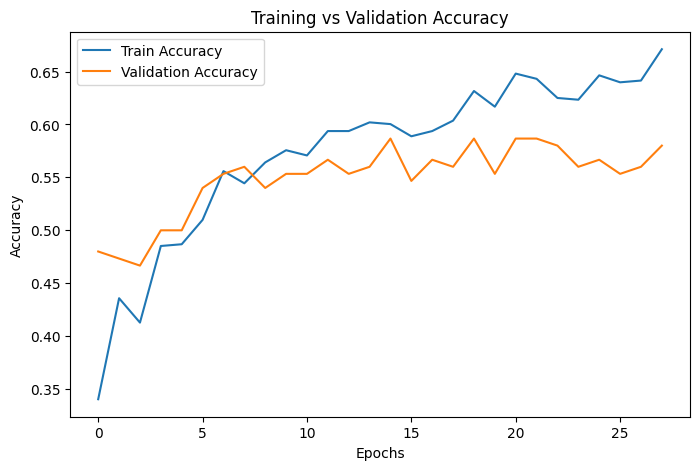

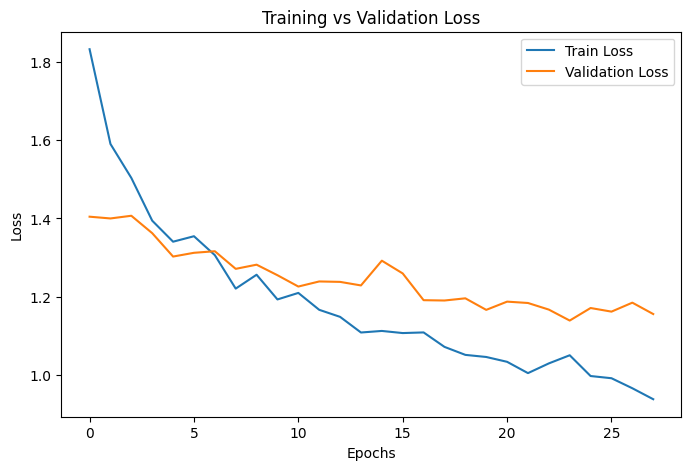

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,446,484 (249.66 MB)

 Trainable params: 16,910,598 (64.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 33,821,198 (129.02 MB)

In [5]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

history=model.fit(
    train_generator,
    epochs=28,
    validation_data=validation_generator
)

# Accuracy plot
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

model.summary()

#### Step 6: Model Evaluation

2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.7055 - loss: 1.0723
Test accuracy: 0.7066666483879089


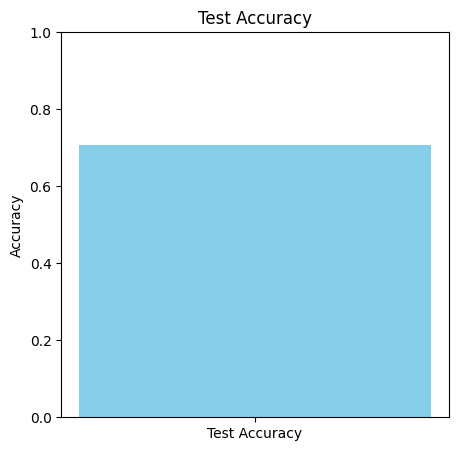

In [6]:
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test accuracy: {test_acc}')

# Visualization
plt.figure(figsize=(5,5))
plt.bar(['Test Accuracy'], [test_acc], color='skyblue')
plt.ylim(0,1)
plt.title("Test Accuracy")
plt.ylabel("Accuracy")
plt.show()

#### Step 7: Model Predictions

In [7]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Path to the image for test
image_path = '/kaggle/input/autistic-children-emotions-dr-fatma-m-talaat/Autistic Children Emotions - Dr. Fatma M. Talaat/Test/fear/13.jpg'

img = image.load_img(image_path, target_size=(256,256))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0  # Normalize the pixel values to be between 0 and 1

predictions = model.predict(img_array)

emotion_labels = ['Surprise', 'Delight', 'Sadness', 'Fear', 'Joy', 'Anger']
predicted_emotion = emotion_labels[np.argmax(predictions)]

print(f'The predicted emotion is: {predicted_emotion}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
The predicted emotion is: Fear


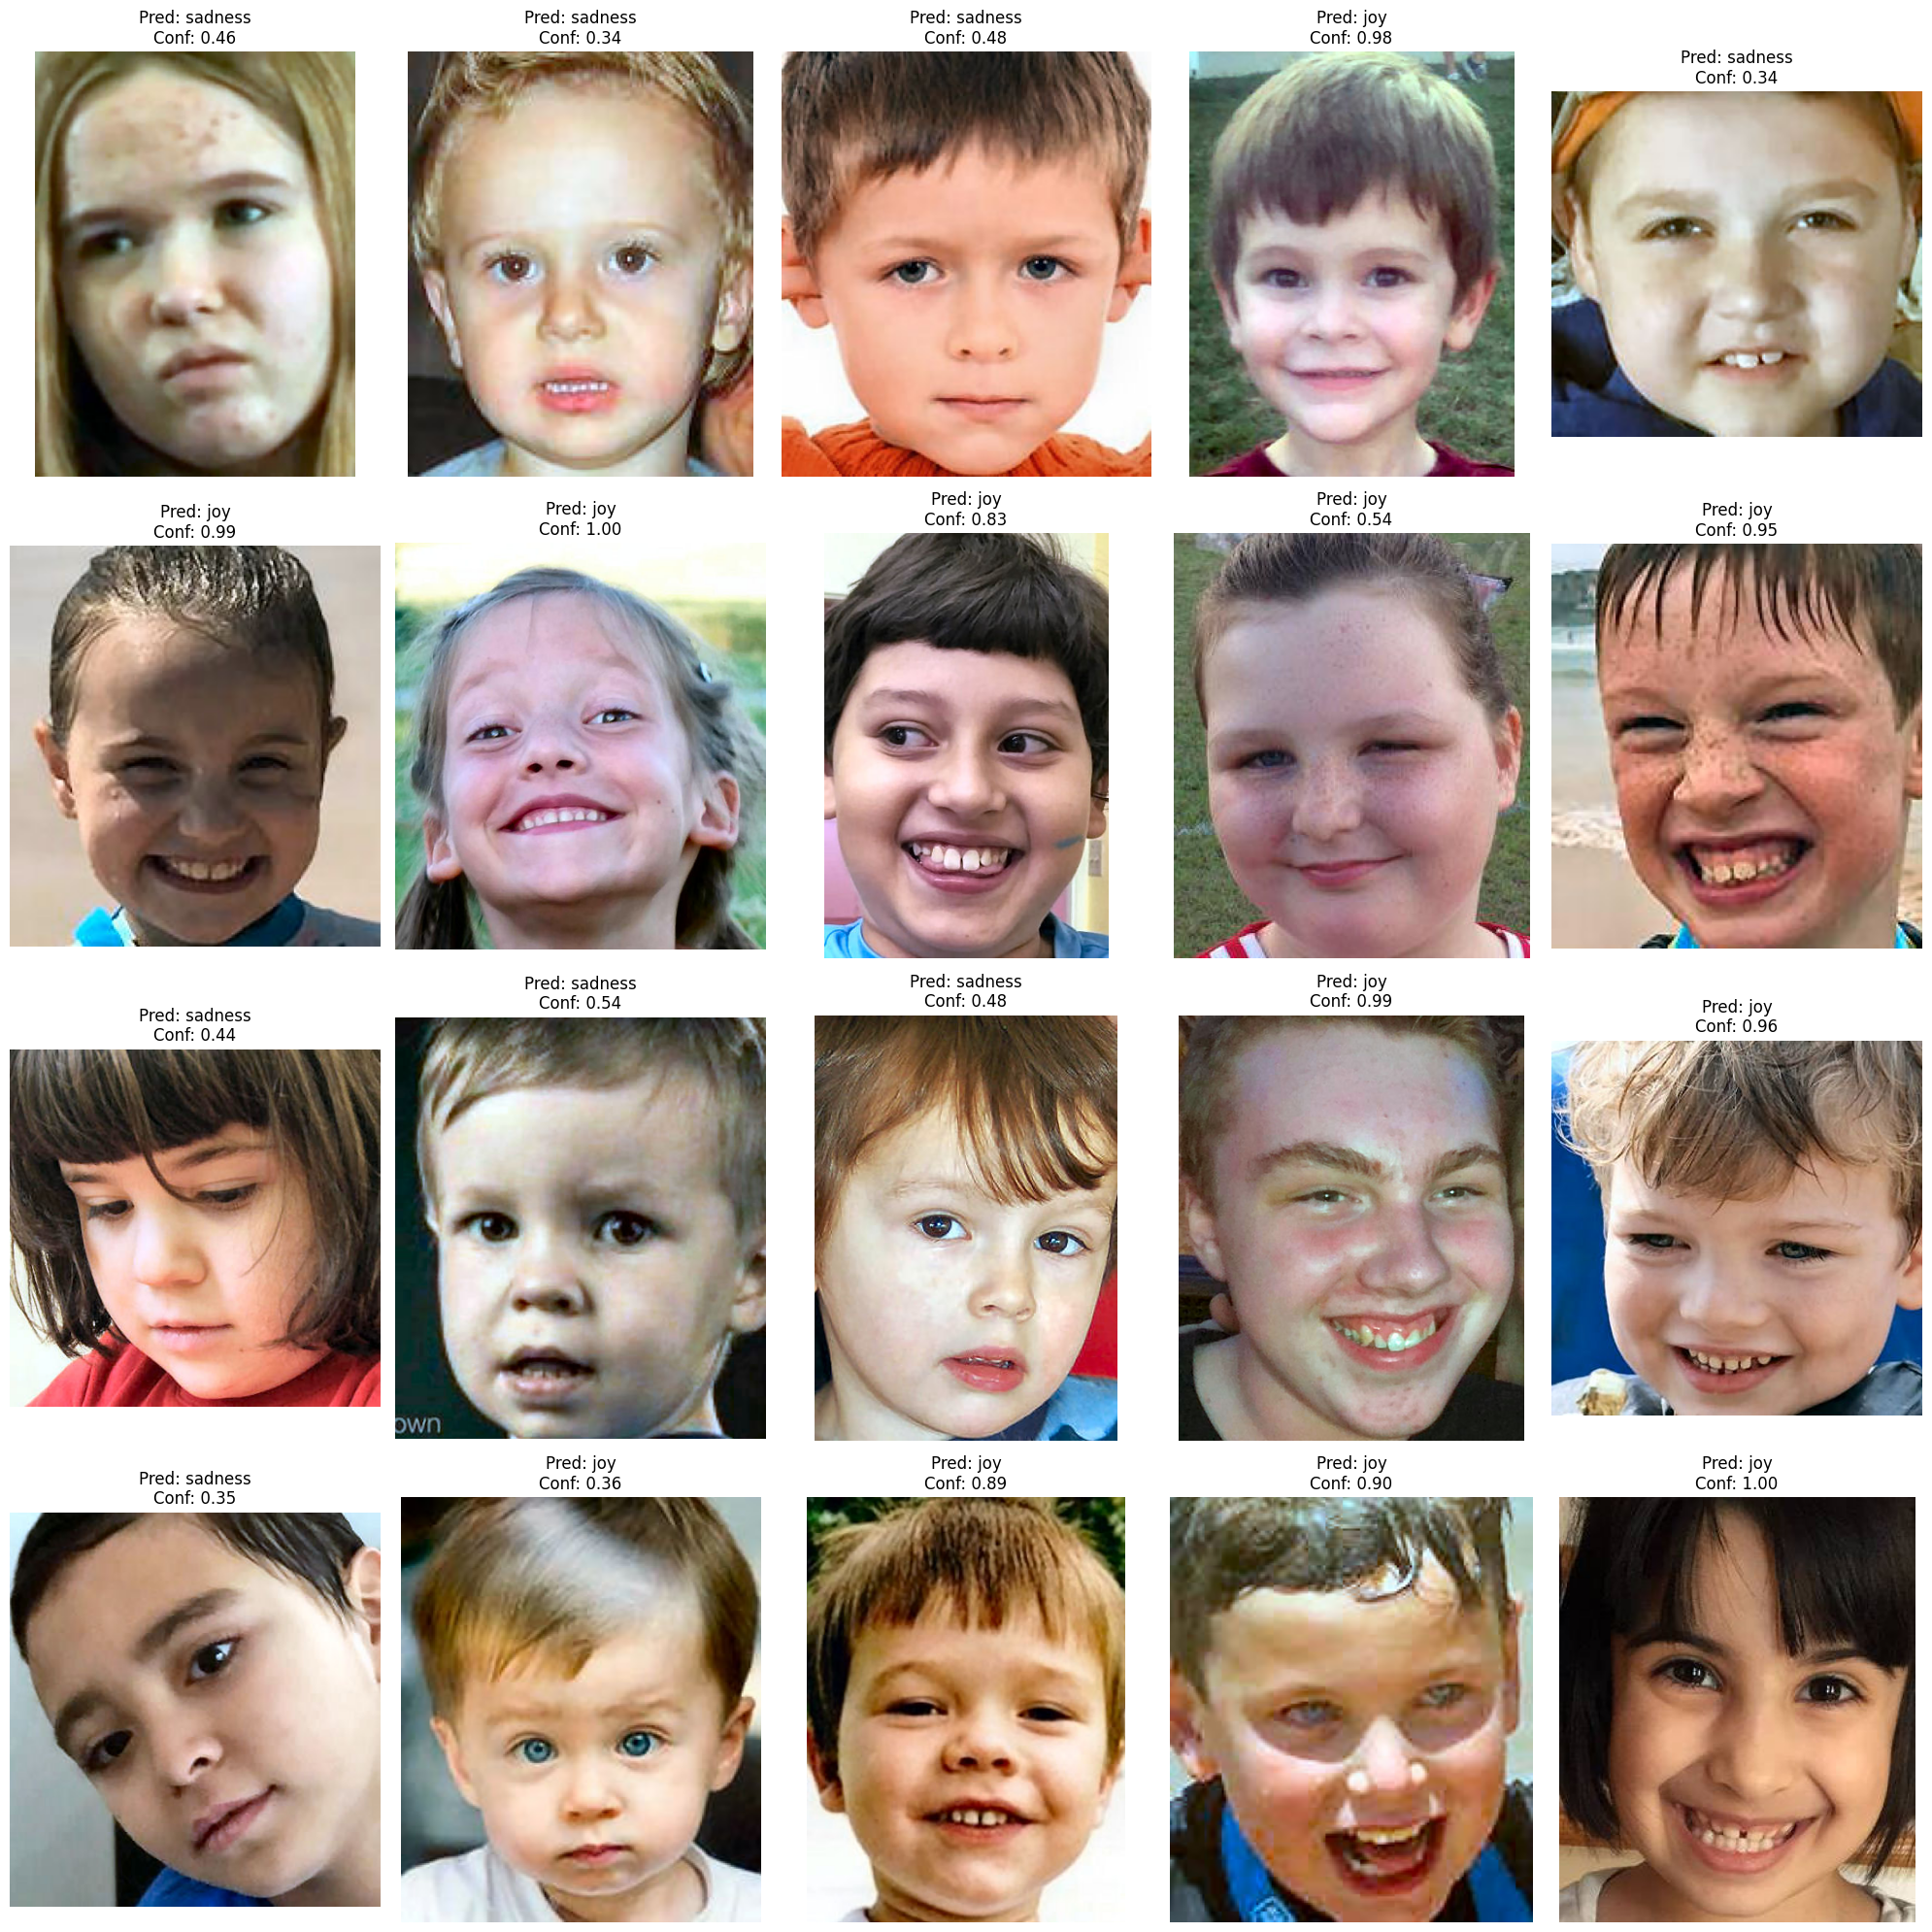

In [8]:
import numpy as np
import random
from tensorflow.keras.preprocessing import image

emotion_labels = list(train_generator.class_indices.keys())

# Pick 20 random indices from test set
random_indices = random.sample(range(len(test_generator.filenames)), 20)

plt.figure(figsize=(20,20))

for i, idx in enumerate(random_indices):
    img_path = test_generator.filepaths[idx]
    img = image.load_img(img_path, target_size=(256,256))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    prediction = model.predict(img_array, verbose=0)
    predicted_label = emotion_labels[np.argmax(prediction)]
    confidence = np.max(prediction)
    
    # Plot
    plt.subplot(4,5,i+1)
    plt.imshow(image.load_img(img_path))
    plt.axis("off")
    plt.title(f"Pred: {predicted_label}\nConf: {confidence:.2f}")
    
plt.tight_layout()
plt.show()